# Practica 5 

**Estudiantes:**

Karen Agudelo Toro 

Luisa María Hernández Quintero 

### Marco Teórico

El proceso de conversión analógica-digital se rige por el Teorema de Muestreo de Nyquist-Shannon. Este principio establece que para reconstruir una señal continua sin pérdida de información ni aliasing (solapamiento espectral), la frecuencia de muestreo ($F_s$) debe ser estrictamente mayor al doble de la frecuencia máxima ($F_{max}$) de la señal [1]:$$F_s > 2 \cdot F_{max}$$Esta frontera teórica implica capturar únicamente dos muestras por ciclo. Aunque matemáticamente este volumen de datos es suficiente para almacenar la información, es insuficiente para la visualización directa en pantallas digitales [2]. Los graficadores estándar utilizan interpolación lineal (unir puntos con segmentos rectos mediante funciones como plt.plot()), lo que transforma las sinusoides en ondas rígidas y angulares [3].Para resolver esta limitación visual, se aplica el sobremuestreo (oversampling), configurando la tasa de muestreo entre 10 y 20 veces por encima de $F_{max}$ [4]. Esto incrementa la densidad de puntos por ciclo, reduciendo la distancia entre muestras y permitiendo que la aproximación lineal emule con alta precisión las curvas analógicas continuas originales [3].


El análisis en tiempo discreto evalúa señales en función de un índice entero $n$, donde $t = n \cdot T$. Para que una señal discreta sea periódica, debe cumplir estrictamente que $x(n) = x(n + N)$, donde el periodo $N$ es obligatoriamente un número entero positivo de muestras [2].A diferencia del dominio continuo, la periodicidad de una sinusoide discreta exige que su frecuencia digital $f_0$ sea un número racional ($f_0 = k/N$) [1]. Cuando la señal es compleja y resulta de la suma de múltiples armónicos, el periodo fundamental del sistema ($N_{total}$) no depende de una sola componente, sino que se calcula mediante el Mínimo Común Múltiplo (m.c.m.) de los periodos individuales de todas las ondas involucradas [2, 3].

In [124]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import scipy.io as sio
from scipy import signal, fft
from scipy.signal import butter, filtfilt, welch as pwelch

## 4.1 Creación de señal compuesta 

In [ ]:
Fo = 40 # Frecuencia fundamental de la señal1
Fo1 = 80 # Frecuencia fundamental de la señal2
Fo2 = 160 # Frecuencia fundamental de la señal3
Tp= 1/40 # Periodo de la señal

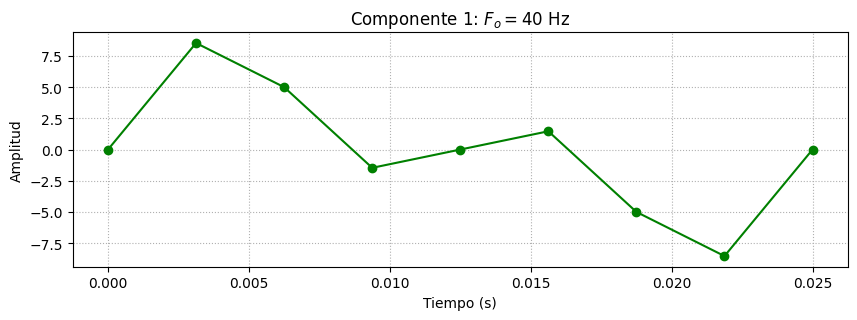

In [129]:
Fs = 2*Fo2 # Frecuencia de muestreo
T = 1/Fs # Periodo de muestreo
t = np.arange(0, Tp+T, T) # Tiempo para un ciclo de la señal con duración de Tp más
A = 5
A1 = 5
A2 = 5
x = A*np.sin(2*np.pi*Fo*t)
x1 = A1*np.sin(2*np.pi*Fo1*t)
x2 = A2*np.sin(2*np.pi*Fo2*t)

xt=x+x1+x2


plt.figure(figsize=(10, 14))
plt.subplot(4, 1, 1)  
plt.plot(t, xt, marker='o', color='g')
plt.title('Componente 1: $F_o = 40$ Hz')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True, linestyle=':')


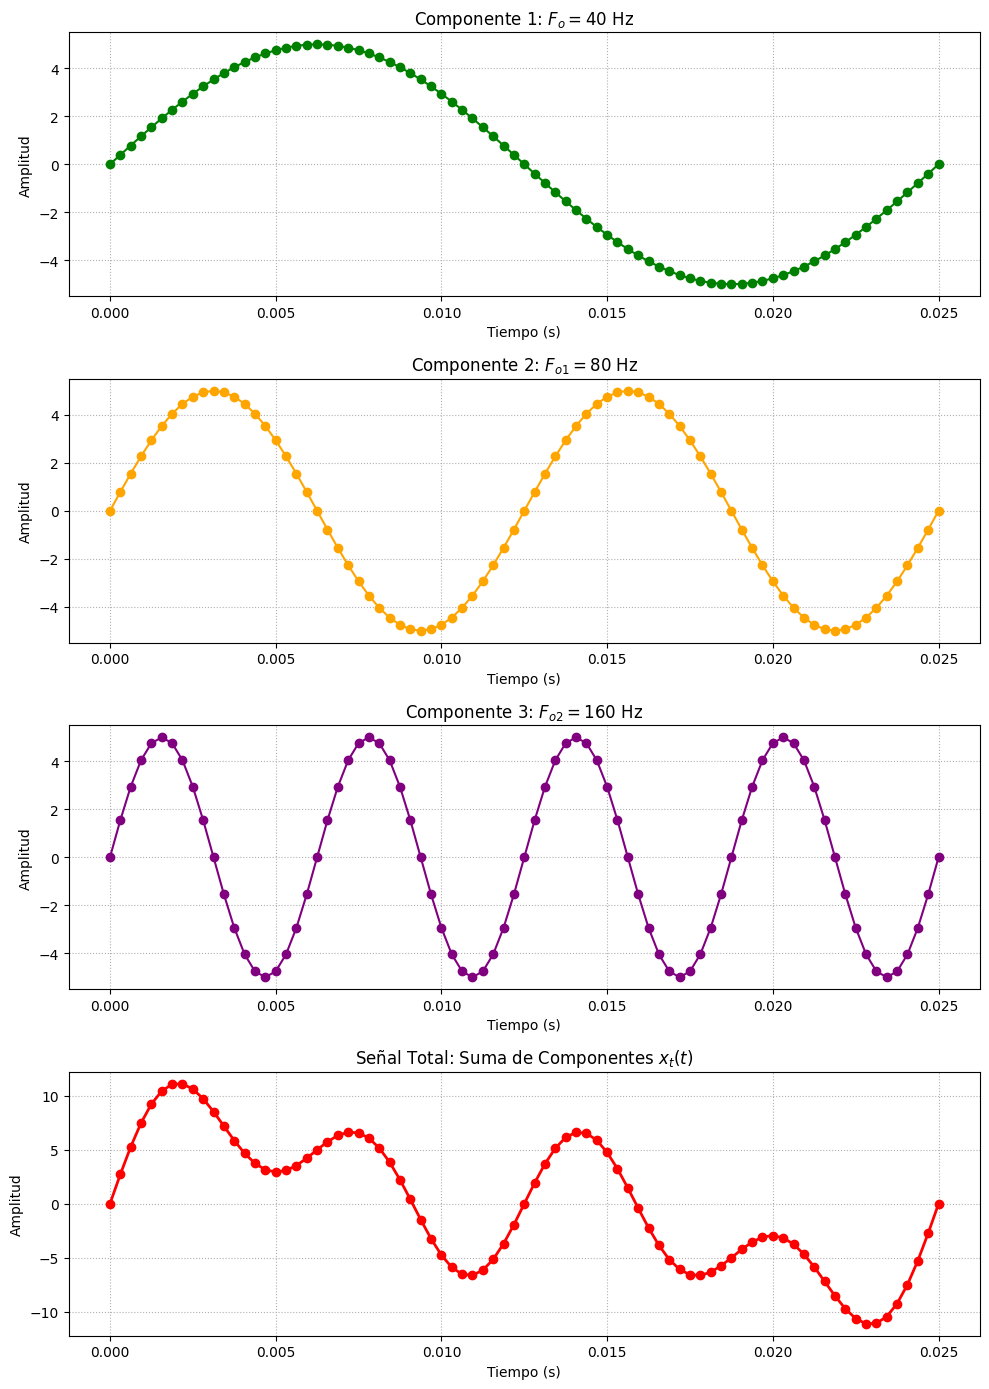

In [130]:



Fs = 20*Fo2 # Frecuencia de muestreo
T = 1/Fs # Periodo de muestreo
t = np.arange(0, Tp+T, T) # Tiempo para un ciclo de la señal con duración de Tp más
A = 5
A1 = 5
A2 = 5
x = A*np.sin(2*np.pi*Fo*t)
x1 = A1*np.sin(2*np.pi*Fo1*t)
x2 = A2*np.sin(2*np.pi*Fo2*t)

xt=x+x1+x2


plt.figure(figsize=(10, 14))

# 1. Primer Componente (40 Hz) 
plt.subplot(4, 1, 1)  
plt.plot(t, x, marker='o', color='g')
plt.title('Componente 1: $F_o = 40$ Hz')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True, linestyle=':')

# 2. Segundo Componente (80 Hz) 
plt.subplot(4, 1, 2)  
plt.plot(t, x1, marker='o', color='orange')
plt.title('Componente 2: $F_{o1} = 80$ Hz')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True, linestyle=':')

# 3. Tercer Componente (160 Hz)
plt.subplot(4, 1, 3) 
plt.plot(t, x2, marker='o', color='purple')
plt.title('Componente 3: $F_{o2} = 160$ Hz')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True, linestyle=':')

# 4. Señal Suma Total 
plt.subplot(4, 1, 4)  
plt.plot(t, xt, marker='o', color='red', linewidth=2)
plt.title('Señal Total: Suma de Componentes $x_t(t)$')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True, linestyle=':')

# Ajuste automático de márgenes para que no se solapen textos
plt.tight_layout()

# Mostrar la ventana con las gráficas en pila
plt.show()

La señal simulada ($x_t$) combina tres componentes armónicas de $40\text{ Hz}$, $80\text{ Hz}$ y $160\text{ Hz}$, siendo la frecuencia máxima del sistema $F_{max} = 160\text{ Hz}$.Si se hubiera aplicado el límite estricto de Nyquist ($F_s = 2 \cdot 160 = 320\text{ Hz}$), la componente más rápida contaría con solo dos puntos por ciclo. Al graficarla, la unión de estos puntos distantes habría destruido la suavidad de la curva, generando una apariencia artificial triangular o en "bloques cuadrados" [2].Para garantizar una resolución gráfica natural, se implementó un sobremuestreo de 20 veces la frecuencia mayor:$$F_s = 20 \cdot 160\text{ Hz} = 3200\text{ Hz}$$Los resultados demuestran la efectividad de esta selección. Al disponer de 20 muestras por ciclo para la onda de $160\text{ Hz}$, la distancia temporal en el arreglo t se vuelve tan pequeña que las uniones lineales son imperceptibles al ojo humano, revelando curvas fluidas.Esta resolución temporal fue indispensable para evaluar la señal suma total $x_t(t)$. La interacción de los tres armónicos genera patrones complejos de interferencia con picos y valles muy específicos. Un muestreo crítico de $320\text{ Hz}$ habría omitido estos máximos y mínimos locales, atenuando artificialmente la amplitud y ocultando la morfología real de la mezcla [4]. Por lo tanto, la elección de $F_s = 3200\text{ Hz}$ se justifica plenamente al aportar fidelidad visual y coherencia física al análisis.

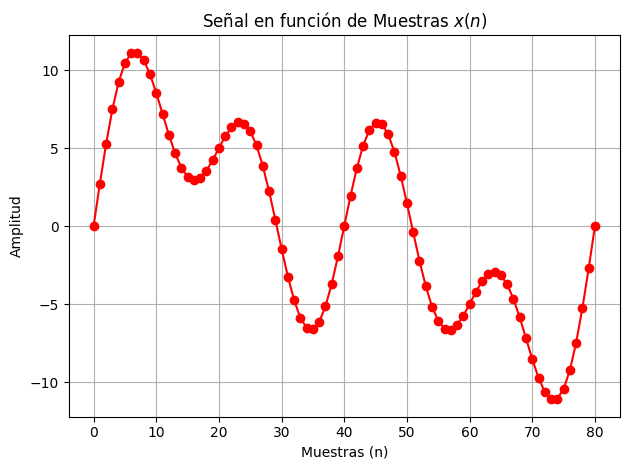

In [42]:
# 1. Frecuencias digitales normalizadas (fo = Fo / Fs)
fo1 = Fo / Fs
fo2 = Fo1 / Fs
fo3 = Fo2 / Fs

# 2. Vector de muestras (n) desde 0 hasta el largo del vector de tiempo anterior
n = np.arange(0, len(t))

# 3. Generación de la señal usando n y las frecuencias normalizadas
x_n1 = A * np.sin(2 * np.pi * fo1 * n)
x_n2 = A1 * np.sin(2 * np.pi * fo2 * n)
x_n3 = A2 * np.sin(2 * np.pi * fo3 * n)
xn = x_n1 + x_n2 + x_n3

# Gráfica en muestras

plt.plot(n, xn, marker='o', color='r')
plt.title('Señal en función de Muestras $x(n)$')
plt.xlabel('Muestras (n)')
plt.ylabel('Amplitud')
plt.grid(True)

plt.tight_layout()
plt.show()

A través de la inspección visual directa de la gráfica roja "Señal en función de Muestras $x(n)$", se demuestra la naturaleza periódica de esta señal compuesta.Siguiendo el recorrido de la onda desde su origen en $(0,0)$:Sube hasta un pico máximo de $11$ en la muestra $7$.Realiza una oscilación secundaria (pico menor de $6.5$) en la muestra $24$.Completa su ciclo y cruza el cero exactamente en la muestra 40.A partir de la muestra 40, la señal repite de forma idéntica el mismo patrón: alcanza el pico alto en la muestra $47$ ($40 + 7$), la oscilación menor en la muestra $64$ ($40 + 24$) y finaliza el segundo ciclo en la muestra 80.Esta repetición exacta comprueba matemáticamente que $x(n) = x(n + 40)$. Por lo tanto, el periodo fundamental de esta señal compleja es de $N = 40$ muestras. Este valor representa el m.c.m. de los periodos de los armónicos que interactúan en el sistema, confirmando que la frecuencia de muestreo elegida posee la resolución temporal adecuada para capturar tanto la morfología general de la onda como sus interferencias internas [3].

In [131]:
# Tomamos las primeras 5 muestras de la señal en tiempo continuo (xt)
cinco_continuas = xt[:5]

# Tomamos las primeras 5 muestras de la señal en tiempo discreto (xn)
cinco_discretas = xn[:5]

# Imprimimos los valores para compararlos visualmente
print("Primeras 5 muestras de la señal continua (xt):")
print(cinco_continuas)

print("\nPrimeras 5 muestras de la señal discreta (xn):")
print(cinco_discretas)

# Comprobación lógica automática
son_iguales = np.allclose(cinco_continuas, cinco_discretas)
print(f"\n¿Los valores son exactamente iguales?: {son_iguales}")

Primeras 5 muestras de la señal continua (xt):
[0.         2.71955278 5.26618356 7.48226429 9.23929381]

Primeras 5 muestras de la señal discreta (xn):
[0.         2.71955278 5.26618356 7.48226429 9.23929381]

¿Los valores son exactamente iguales?: True


Los resultados en la consola confirman que el vector de la señal continua y el de la señal discreta son idénticos. Esto valida por qué la función lógica retornó un resultado verdadero.

Este comportamiento se debe a que el proceso de muestreo no altera las amplitudes ni las frecuencias de la onda original; simplemente limita los momentos en los que se registran los datos. Evaluar la señal analógica en los instantes de tiempo reales equivale exactamente a evaluar la señal discreta en sus índices enteros correspondientes.

La coincidencia numérica en las primeras cinco posiciones comprueba que la indexación de muestras se sincroniza perfectamente con el paso del tiempo físico del sistema. En conclusión, el experimento demuestra que la señal digitalizada conserva de manera exacta y fiel la información de los puntos medidos de su contraparte analógica.

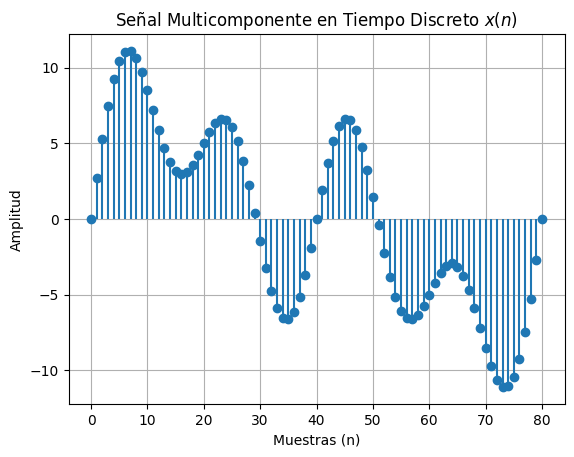

In [43]:
# Usamos stem en lugar de plot para ver los pulsos discretos
plt.stem(n, xn, basefmt=" ")

plt.title('Señal Multicomponente en Tiempo Discreto $x(n)$')
plt.xlabel('Muestras (n)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.show()

## 4.2 Cálculo de trasformada de Fourier 

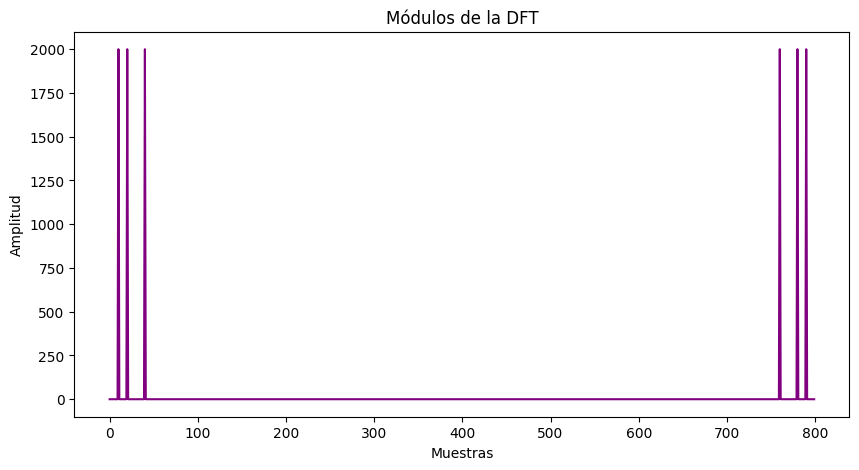

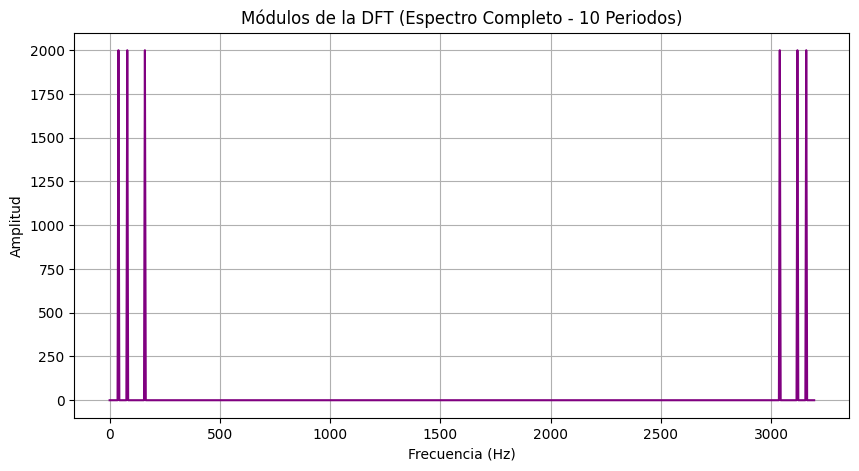

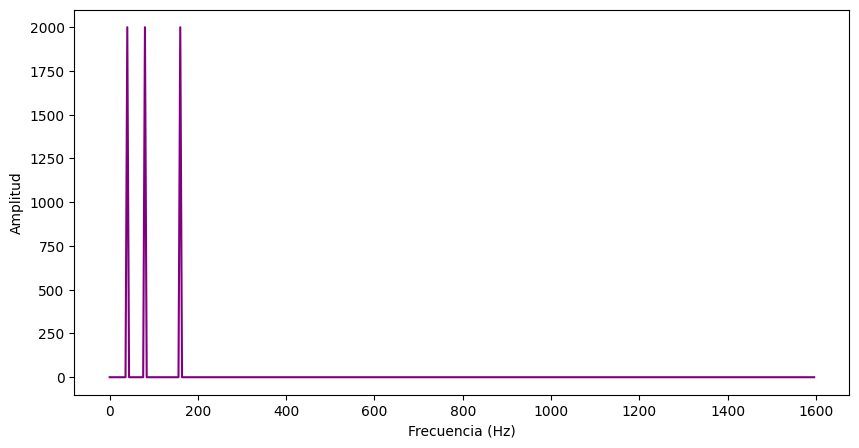

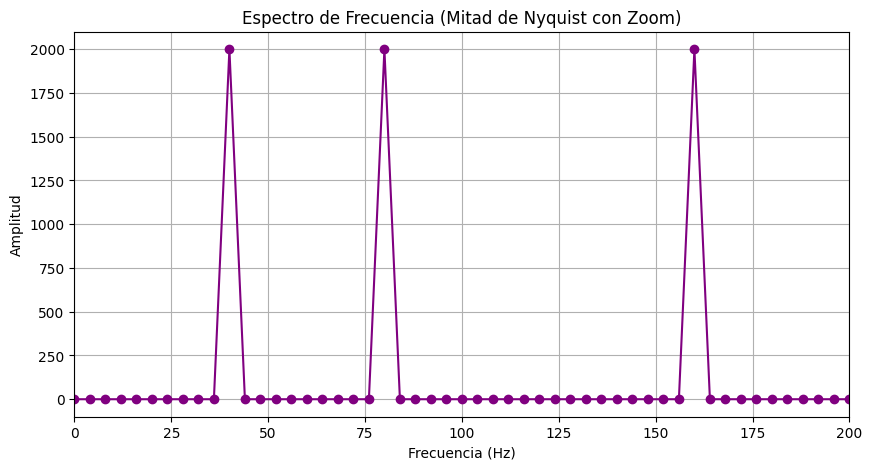

Número total de muestras (N): 800
Altura de los picos en el gráfico: 2000.0


In [126]:
# Un periodo de la fundamental es Tp = 1/40 = 0.025s
# Para 10 periodos la duración total es 10 * Tp = 0.25s
Tp = 1/Fo 
t_10 = np.arange(0, 10 * Tp, T) 

# Amplitudes de las componentes
A1, A2, A3 = 5, 5, 5

# Generación de la señal suma de las 3 sinusoides
x10 = (A1 * np.sin(2 * np.pi * Fo * t_10) + 
       A2 * np.sin(2 * np.pi * Fo1 * t_10) + 
       A3 * np.sin(2 * np.pi * Fo2* t_10))



# CÁLCULO DE LA TRANSFORMADA DE FOURIER (DFT)
X10 = np.fft.fft(x10)
N = len(X10)  # Número de muestras (800 puntos debido a Fs=3200)
plt.figure(figsize=(10, 5))
plt.plot(abs(X10),'purple')
plt.title('Módulos de la DFT')
plt.xlabel('Muestras')
plt.ylabel('Amplitud')
plt.show()


# GRÁFICA 1: ESPECTRO COMPLETO ESCALADO EN FRECUENCIA (Como la guía)
F = np.arange(0, N) * Fs / N

plt.figure(figsize=(10, 5))
plt.plot(F, abs(X10), color='purple')
plt.title('Módulos de la DFT (Espectro Completo - 10 Periodos)')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 5))
Nmitad = int(np.ceil(N/2))
Fmitad = np.arange(0,Nmitad)*Fs/N
X10mitad = X10[0:Nmitad]
plt.plot(Fmitad,abs(X10mitad),'purple')
plt.ylabel('Amplitud')
plt.xlabel('Frecuencia (Hz)')
plt.show()


# GRÁFICA 2: MITAD DE NYQUIST CON ZOOM (Para identificar frecuencias)
Nmitad = int(np.ceil(N / 2))
Fmitad = F[0:Nmitad]
X10mitad = X10[0:Nmitad]

plt.figure(figsize=(10, 5))
plt.plot(Fmitad, abs(X10mitad), marker='o', color='purple')
plt.title('Espectro de Frecuencia (Mitad de Nyquist con Zoom)')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud')

# Hacemos zoom entre 0 y 200 Hz para identificar claramente los 3 picos
plt.xlim(0, 200) 
plt.grid(True)
plt.show()

print(f"Número total de muestras (N): {N}")
print(f"Altura de los picos en el gráfico: {N * 2.5}")

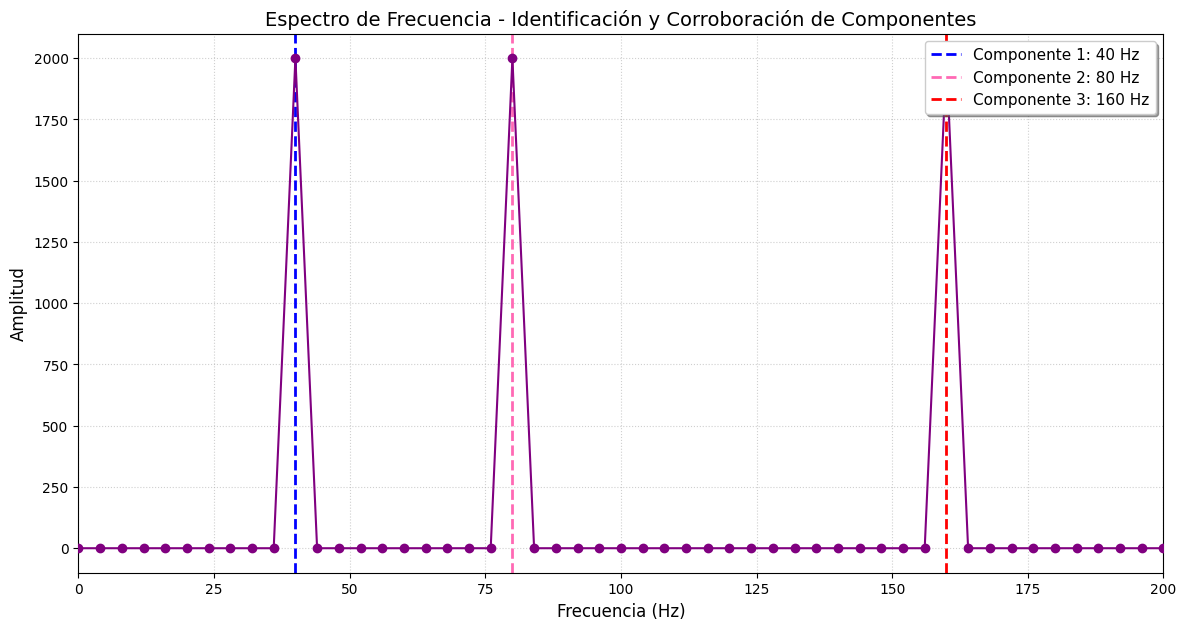

In [128]:
plt.figure(figsize=(14, 7))
plt.plot(Fmitad, abs(X10mitad), marker='o', color='purple', linestyle='-', linewidth=1.5, zorder=3)
plt.title('Espectro de Frecuencia - Identificación y Corroboración de Componentes', fontsize=14)
plt.xlabel('Frecuencia (Hz)', fontsize=12)
plt.ylabel('Amplitud', fontsize=12)
plt.axvline(x=40, color='blue', linestyle='--', linewidth=2, label='Componente 1: 40 Hz', zorder=2)
plt.axvline(x=80, color='hotpink', linestyle='--', linewidth=2, label='Componente 2: 80 Hz', zorder=2)
plt.axvline(x=160, color='red', linestyle='--', linewidth=2, label='Componente 3: 160 Hz', zorder=2)
plt.xlim(0, 200) 
plt.legend(loc='upper right', fontsize=11, shadow=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## 4.3 Cálculo de la transformada inversa de Fourier

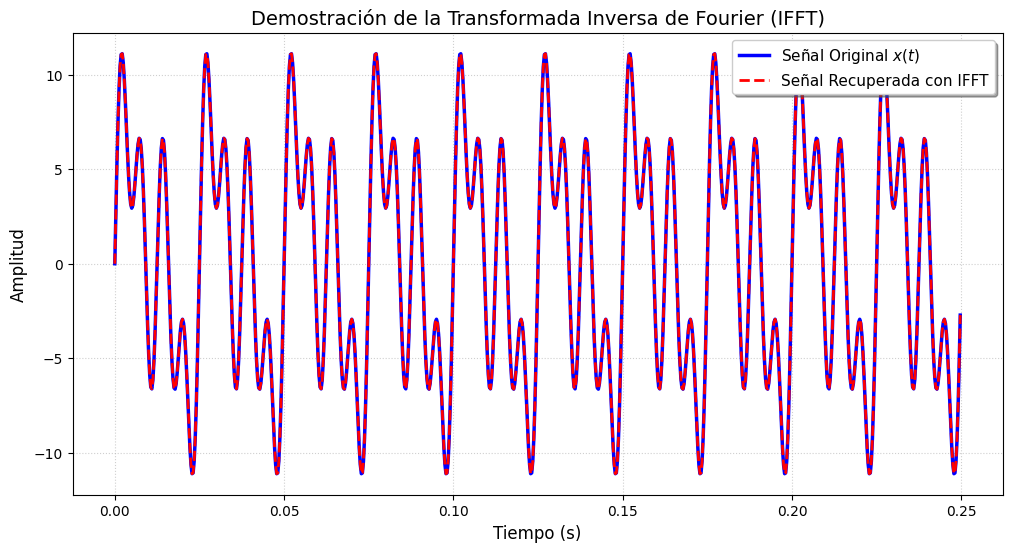

Error máximo de reconstrucción: 7.105427357601002e-15


In [46]:

# TRANSFORMADA INVERSA (IFFT) 
# Aplicamos la transformada inversa al espectro completo
x_reconstruida_compleja = np.fft.ifft(X10)

# Extraemos solo la parte real para limpiar residuos matemáticos insignificantes
x_reconstruida = np.real(x_reconstruida_compleja)

# 4. GRÁFICA DE COMPARACIÓN (COMPROBACIÓN DE RECONSTRUCCIÓN)
plt.figure(figsize=(12, 6))

# Graficamos la señal original con una línea azul continua
plt.plot(t_10, x10, color='blue', label='Señal Original $x(t)$', linewidth=2.5)

# Graficamos la señal reconstruida encima usando puntos rojos discontinuos
plt.plot(t_10, x_reconstruida, color='red', linestyle='--', label='Señal Recuperada con IFFT', linewidth=2)

plt.title('Demostración de la Transformada Inversa de Fourier (IFFT)', fontsize=14)
plt.xlabel('Tiempo (s)', fontsize=12)
plt.ylabel('Amplitud', fontsize=12)
plt.legend(loc='upper right', fontsize=11, shadow=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()



# 5. VERIFICACIÓN MATEMÁTICA EN CONSOLA
# Si la diferencia máxima entre ambas señales tiende a cero, la reconstrucción fue perfecta
error_maximo = np.max(np.abs(x10 - x_reconstruida))
print(f"Error máximo de reconstrucción: {error_maximo}")

## 4.4 

## 4.5 Anánalisis de señal ECG

In [67]:
# Cargar archivo .mat
data = sio.loadmat('senecg.mat')

#Transforme el vector a 1D
ecg=data['ECG'].squeeze()

fs = 250  # frecuencia de muestreo [Hz]
t = np.arange(0, 1/fs*len(ecg), 1/fs)

print(max(t))
print(len(ecg)/max(t))

# Extraer cada componente por separado
def extraer_componente(x, indice_inicio, indice_fin):
    "Extrae una componente frecuencial específica"
    F = np.fft.fft(x)
    F_filtrado = np.zeros(len(F), dtype=complex)
    F_filtrado[indice_inicio:indice_fin] = F[indice_inicio:indice_fin]
    # También incluir la parte simétrica
    F_filtrado[-indice_fin:-indice_inicio] = F[-indice_fin:-indice_inicio]
    return np.fft.ifft(F_filtrado)

4.996
250.20016012810245


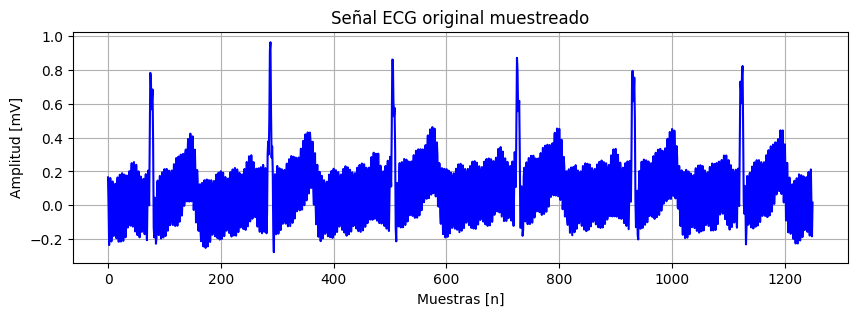

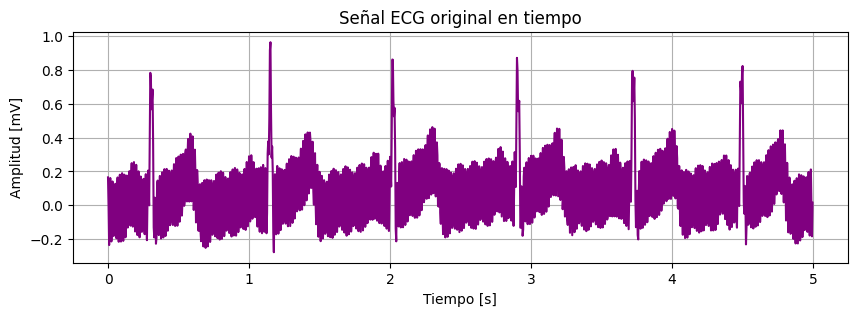

In [61]:
#Visualizar señal original por cantidad de muestras
plt.figure(figsize=(10,3))
plt.plot(ecg, color='b')
plt.title('Señal ECG original muestreado')
plt.xlabel('Muestras [n]')
plt.ylabel('Amplitud [mV]')
plt.grid(True)
plt.show()

# Visualizar señal original por tiempo
plt.figure(figsize=(10,3))
plt.plot(t, ecg, color='purple')
plt.title('Señal ECG original en tiempo')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [mV]')
plt.grid(True)
plt.show()

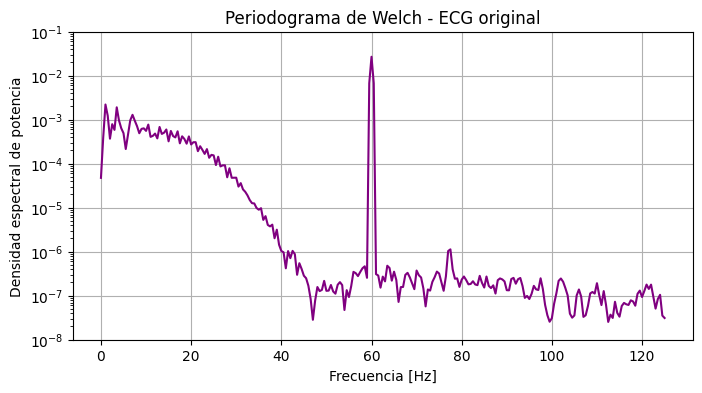

In [65]:
# Periodograma de Welch
nperseg = 500
#Solapamiento de 50%
noverlap = int(nperseg * 0.5) 

f, Pxx = signal.welch(
    ecg, 
    fs=fs, 
    window='hann', 
    nperseg=nperseg, 
    noverlap=noverlap
    )

plt.figure(figsize=(8,4))
plt.semilogy(f, Pxx,'purple')
plt.ylim(1e-8, 1e-1)
plt.title('Periodograma de Welch - ECG original')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad espectral de potencia')
plt.grid(True)
plt.show()

c:\Users\lmari\miniconda3\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\lmari\miniconda3\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


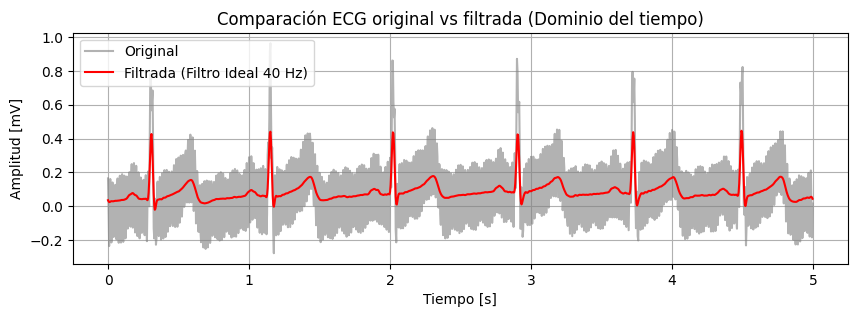

In [68]:
f_corte = 40 # Frecuencia de corte
ind_fc = int(np.round(f_corte * len(ecg) / fs))
ind_ic = 0 # Para filtro pasa-bajas, iniciamos en 0 Hz (DC)

# Se extrae todo el contenido desde 0 Hz hasta 40 Hz.
ecg_filtrado = extraer_componente(ecg, ind_ic, ind_fc)

# Comparar señales en el Dominio del Tiempo
plt.figure(figsize=(10,3))
plt.plot(t, ecg, color='gray', label='Original', alpha=0.6)
plt.plot(t, ecg_filtrado, color='r', label='Filtrada (Filtro Ideal 40 Hz)')
plt.title('Comparación ECG original vs filtrada (Dominio del tiempo)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [mV]')
plt.legend()
plt.grid(True)
plt.show()

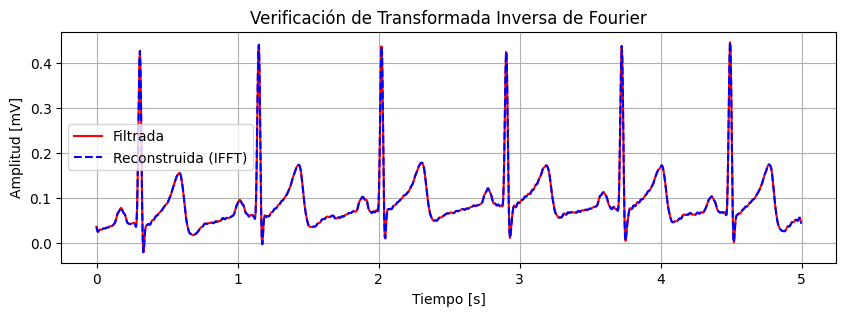

In [69]:
# Transformada inversa de Fourier 
ECG_FFT = fft.fft(ecg_filtrado)
ecg_reconstruida = np.real(fft.ifft(ECG_FFT))

plt.figure(figsize=(10,3))
plt.plot(t, ecg_filtrado, label='Filtrada', color='r')
plt.plot(t, ecg_reconstruida, '--', color='b', label='Reconstruida (IFFT)')
plt.title('Verificación de Transformada Inversa de Fourier')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [mV]')
plt.legend()
plt.grid(True)
plt.show()

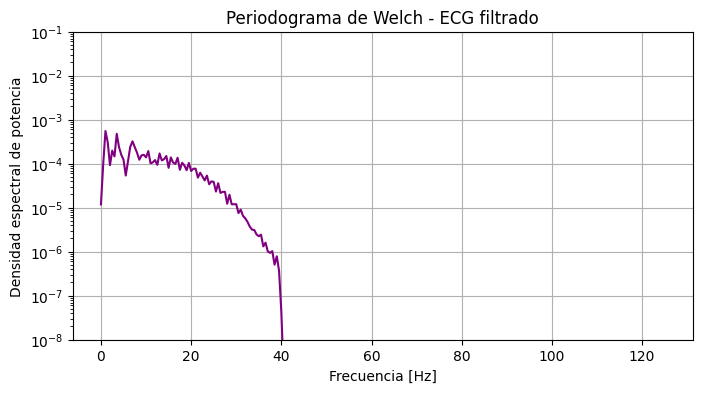

In [70]:
# Periodograma de Welch
nperseg = 500
# Solapamiento de 50%
noverlap = int(nperseg * 0.5) 

f, Pxx = signal.welch(
    ecg_reconstruida, 
    fs=fs, 
    window='hann', 
    nperseg=nperseg, 
    noverlap=noverlap
    )

plt.figure(figsize=(8,4))
plt.semilogy(f, Pxx,'purple')
plt.ylim(1e-8, 1e-1)
plt.title('Periodograma de Welch - ECG filtrado')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad espectral de potencia')
plt.grid(True)
plt.show()

## 4.6 Análisis de ECG Parkinson-control

In [92]:

# INSPECCIÓN DEL PACIENTE CONTROL
data_control = sio.loadmat("control/C012_EP_reposo.mat")
control_crudo = data_control['data']

print("       ESTRUCTURA DEL PACIENTE CONTROL            ")
print(f"Tipo de objeto en Python: {type(control_crudo)}")
print(f"Dimensiones de la matriz original (Shape): {control_crudo.shape}")
print(f"Número de dimensiones: {control_crudo.ndim}")

# INSPECCIÓN DEL PACIENTE PARKINSON
data_parkinson = sio.loadmat("parkinson/P012_EP_reposo.mat")
parkinson_crudo = data_parkinson['data']

print("\n")
print("      ESTRUCTURA DEL PACIENTE PARKINSON           ")
print(f"Tipo de objeto en Python: {type(parkinson_crudo)}")
print(f"Dimensiones de la matriz original (Shape): {parkinson_crudo.shape}")
print(f"Número de dimensiones: {parkinson_crudo.ndim}")


       ESTRUCTURA DEL PACIENTE CONTROL            
Tipo de objeto en Python: <class 'numpy.ndarray'>
Dimensiones de la matriz original (Shape): (8, 2000, 172)
Número de dimensiones: 3


      ESTRUCTURA DEL PACIENTE PARKINSON           
Tipo de objeto en Python: <class 'numpy.ndarray'>
Dimensiones de la matriz original (Shape): (8, 2000, 140)
Número de dimensiones: 3


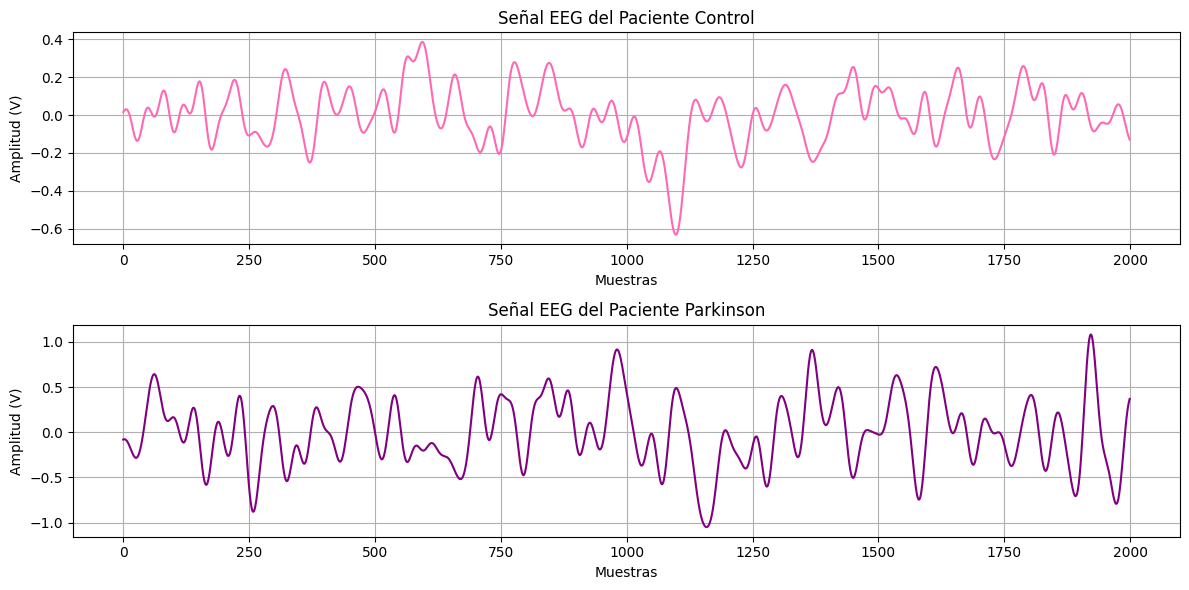

In [104]:
#CONTROL
matriz_control = sio.loadmat("control/C012_EP_reposo.mat")['data']
# Selección el Canal 0 (que corresponde al electrodo C3)
control_epocas = matriz_control[0, :, :]
control = control_epocas.mean(axis=1)


#PARKINSON 
# Cargamos el archivo .mat y extraemos la matriz de datos
matriz_parkinson = sio.loadmat("parkinson/P012_EP_reposo.mat")['data']
parkinson_epocas = matriz_parkinson[0, :, :]
parkinson = parkinson_epocas.mean(axis=1)

# Gráfica de la señal EEG de cada Paciente.
plt.figure(figsize=(12,6))

# Paciente Control.
plt.subplot(2,1,1)
plt.plot(control,'hotpink')
plt.xlabel('Muestras')
plt.ylabel('Amplitud (V)')
plt.title('Señal EEG del Paciente Control')
plt.grid(True)

# Paciente Parkinson.
plt.subplot(2,1,2)
plt.plot(parkinson,'purple')
plt.xlabel('Muestras')
plt.ylabel('Amplitud (V)')
plt.title('Señal EEG del Paciente Parkinson')

plt.tight_layout()
plt.grid(True)
plt.show()

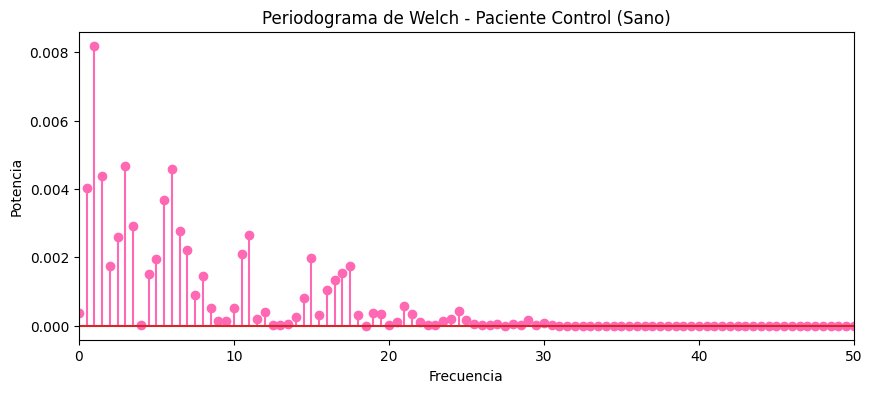

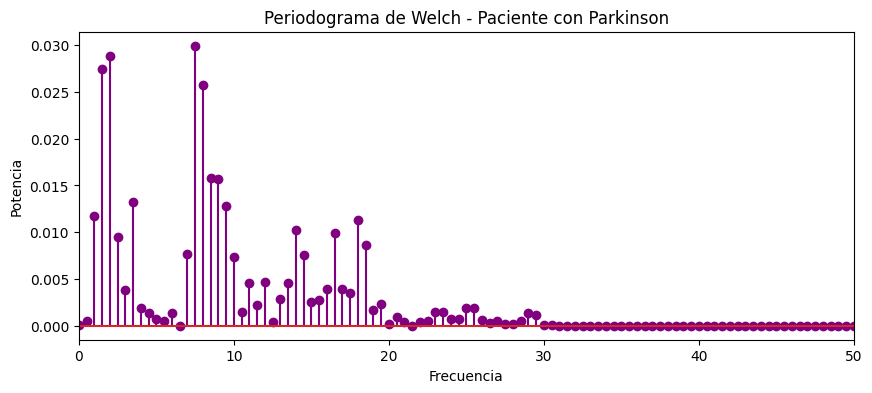

In [120]:

fs = 1000
nperseg = 2000  # Ventana del tamaño total de la señal
f_control, Pxx_control = pwelch(control, fs=fs, window='hann', nperseg=nperseg, noverlap=0)
f_parkinson, Pxx_parkinson = pwelch(parkinson, fs=fs, window='hann', nperseg=nperseg, noverlap=0)


# Gráfica para el Paciente Control 
plt.figure(figsize=(10, 4))
plt.stem(f_control, Pxx_control,'hotpink')
plt.title('Periodograma de Welch - Paciente Control (Sano)')
plt.xlabel('Frecuencia')
plt.ylabel('Potencia')
plt.xlim([0, 50])  
plt.show()

# Gráfica para el Paciente con Parkinson
plt.figure(figsize=(10, 4))
plt.stem(f_parkinson, Pxx_parkinson,'purple')
plt.title('Periodograma de Welch - Paciente con Parkinson')
plt.xlabel('Frecuencia')
plt.ylabel('Potencia')
plt.xlim([0, 50])  
plt.show()

c:\Users\lmari\miniconda3\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\lmari\miniconda3\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


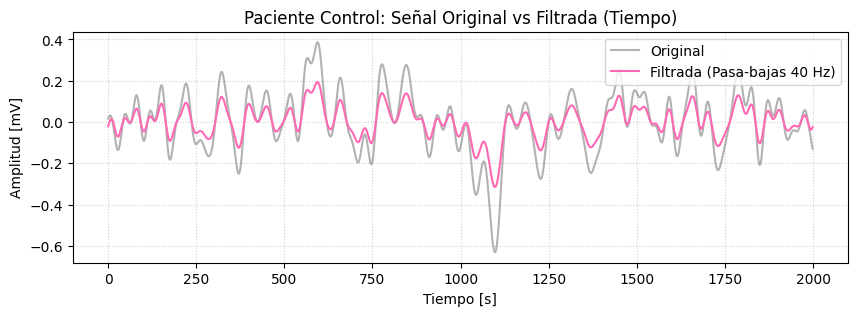

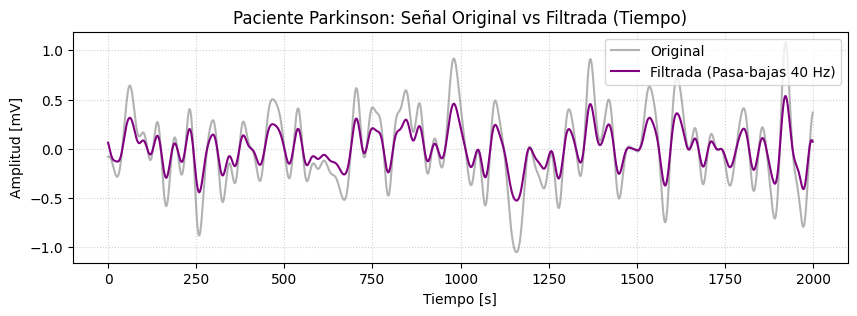

In [121]:

# Definición de la frecuencia de corte en 40 Hz
fc = 40

# Calculo de los índices de inicio y fin para el filtro ideal
ind_inicio = 0
ind_fin = int(np.round(fc * len(control) / fs))

# Calculo de las señales filtradas usando la función del laboratorio
control_filtrada = extraer_componente(control, ind_inicio, ind_fin)
parkinson_filtrada = extraer_componente(parkinson, ind_inicio, ind_fin)

# Definición de la gráfica para el paciente de control
plt.figure(figsize=(10, 3))
plt.plot(control, color='gray', label='Original', alpha=0.6)
plt.plot(control_filtrada, color='hotpink', label='Filtrada (Pasa-bajas 40 Hz)')
plt.title('Paciente Control: Señal Original vs Filtrada (Tiempo)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [mV]')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Definición de la gráfica para el paciente con Parkinson
plt.figure(figsize=(10, 3))
plt.plot(parkinson, color='gray', label='Original', alpha=0.6)
plt.plot(parkinson_filtrada, color='purple', label='Filtrada (Pasa-bajas 40 Hz)')
plt.title('Paciente Parkinson: Señal Original vs Filtrada (Tiempo)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [mV]')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

c:\Users\lmari\miniconda3\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\lmari\miniconda3\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


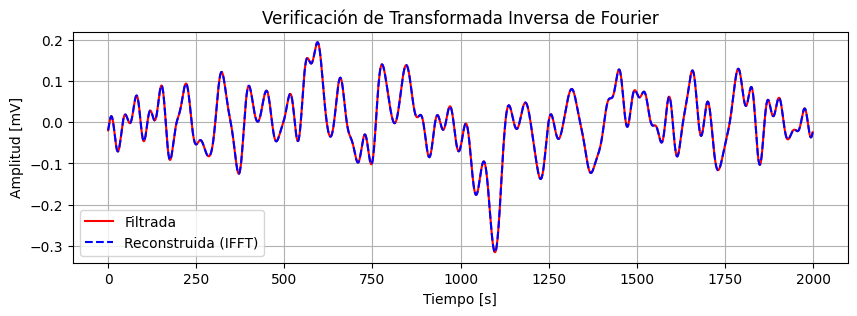

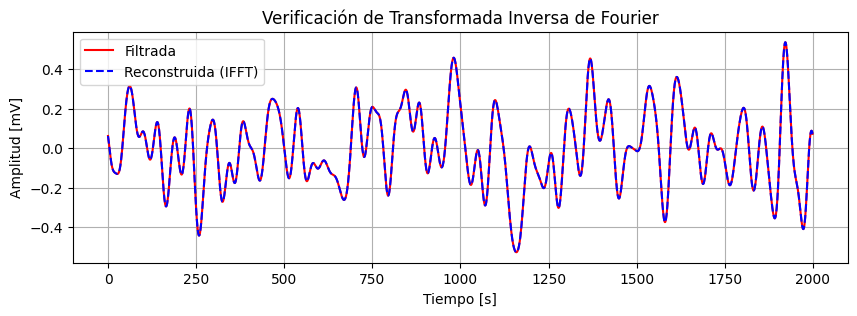

In [122]:
# Transformada inversa de Fourier 
control_FFT = fft.fft(control_filtrada)
control_reconstruida = np.real(fft.ifft(control_FFT))

plt.figure(figsize=(10,3))
plt.plot(control_filtrada, label='Filtrada', color='r')
plt.plot(control_reconstruida, '--', color='b', label='Reconstruida (IFFT)')
plt.title('Verificación de Transformada Inversa de Fourier')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [mV]')
plt.legend()
plt.grid(True)
plt.show()

# Transformada inversa de Fourier 
parkinson_FFT = fft.fft(parkinson_filtrada)
parkinson_reconstruida = np.real(fft.ifft(parkinson_FFT))

plt.figure(figsize=(10,3))
plt.plot(parkinson_filtrada, label='Filtrada', color='r')
plt.plot(parkinson_reconstruida, '--', color='b', label='Reconstruida (IFFT)')
plt.title('Verificación de Transformada Inversa de Fourier')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [mV]')
plt.legend()
plt.grid(True)
plt.show()


## Referencias Bibliográficas


[1] Proakis, J. G., & Manolakis, D. G. (2007). Digital Signal Processing: Principles, Algorithms, and Applications (4th ed.). Pearson Prentice Hall.

[2] Oppenheim, A. V., & Schafer, R. W. (2010). Discrete-Time Signal Processing (3rd ed.). Prentice Hall.

[3] Lathi, B. P., & Green, R. A. (2014). Linear Systems and Signals (3rd ed.). Oxford University Press.

[4] Lyons, R. G. (2010). Understanding Digital Signal Processing (3rd ed.). Prentice Hall.